In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, brier_score_loss

import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold
from xgboost import XGBRegressor, XGBClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.cluster import KMeans

data_path = "./dynamic_supply_chain_logistics_dataset.csv"
df_ori = pd.read_csv(data_path)

# Convert timestamp column to datetime
df_ori['timestamp'] = pd.to_datetime(df_ori['timestamp'])
# df_ori.set_index('timestamp', inplace=True)

# Create risk classification mapping
df = df_ori.copy()
risk_mapping = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2}
df['risk_classification'] = df_ori['risk_classification'].map(risk_mapping)
print(len(df))

32065


In [65]:
# Feature subset relevant for mode inference
mode_features = [
    'fuel_consumption_rate',
    'traffic_congestion_level',
    'eta_variation_hours',
    'delay_probability'
]

df_mode = df[mode_features].copy()

# Handle missing data
df_mode = df_mode.fillna(df_mode.median(numeric_only=True))

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_mode)
kmeans = KMeans(n_clusters=3, random_state=42)
df['mode_cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('mode_cluster')[mode_features].mean()
print(cluster_summary)
mapping = {
    0: 'Truck',   # adjust based on your means
    1: 'Drone',
    2: 'Rail'
}
df['transport_mode'] = df['mode_cluster'].map(mapping)
df = df[df["mode_cluster"] == 0]

              fuel_consumption_rate  traffic_congestion_level  \
mode_cluster                                                    
0                          7.943947                  1.628149   
1                          7.336233                  8.224669   
2                          7.291888                  4.341066   

              eta_variation_hours  delay_probability  
mode_cluster                                          
0                        4.163282           0.704405  
1                        3.897715           0.681380  
2                       -0.604735           0.760891  


In [66]:
mask = (
    df["vehicle_gps_latitude"].between(32.4, 35.8) &
    df["vehicle_gps_longitude"].between(-121.0, -114.0)
)
df = df[mask]
print(len(df))

261


In [64]:
def data_info(data):
    print('1) Number of columns are : ',data.shape[1])
    print('2) Number of rows are : ',data.shape[0])
    print('3) Total number of data-points :',data.size)
    numerical_features = [f for f in data.columns if data[f].dtypes!='O']
    print('4) Count of Numerical Features :',len(numerical_features))
    cat_features = [c for c in data.columns if data[c].dtypes=='O']
    print('5) Count of Categorical Features :',len(cat_features))
data_info(df)

1) Number of columns are :  28
2) Number of rows are :  663
3) Total number of data-points : 18564
4) Count of Numerical Features : 27
5) Count of Categorical Features : 1


In [6]:
def features_with_missing_values(data):
    x = data.isnull().sum().sum()/(data.shape[0]*data.shape[1])*100
    print('Percentage of Total Missing Values is ' ,round(x,2) ,'%')
    print('Missing Value Estimation :')
    for i in data.columns:
        if data[i].isna().sum()>0:
            print('The Feature ',i,' has '+ str(data[i].isna().sum()) + ' missing values')
            
features_with_missing_values(df)

Percentage of Total Missing Values is  0.0 %
Missing Value Estimation :


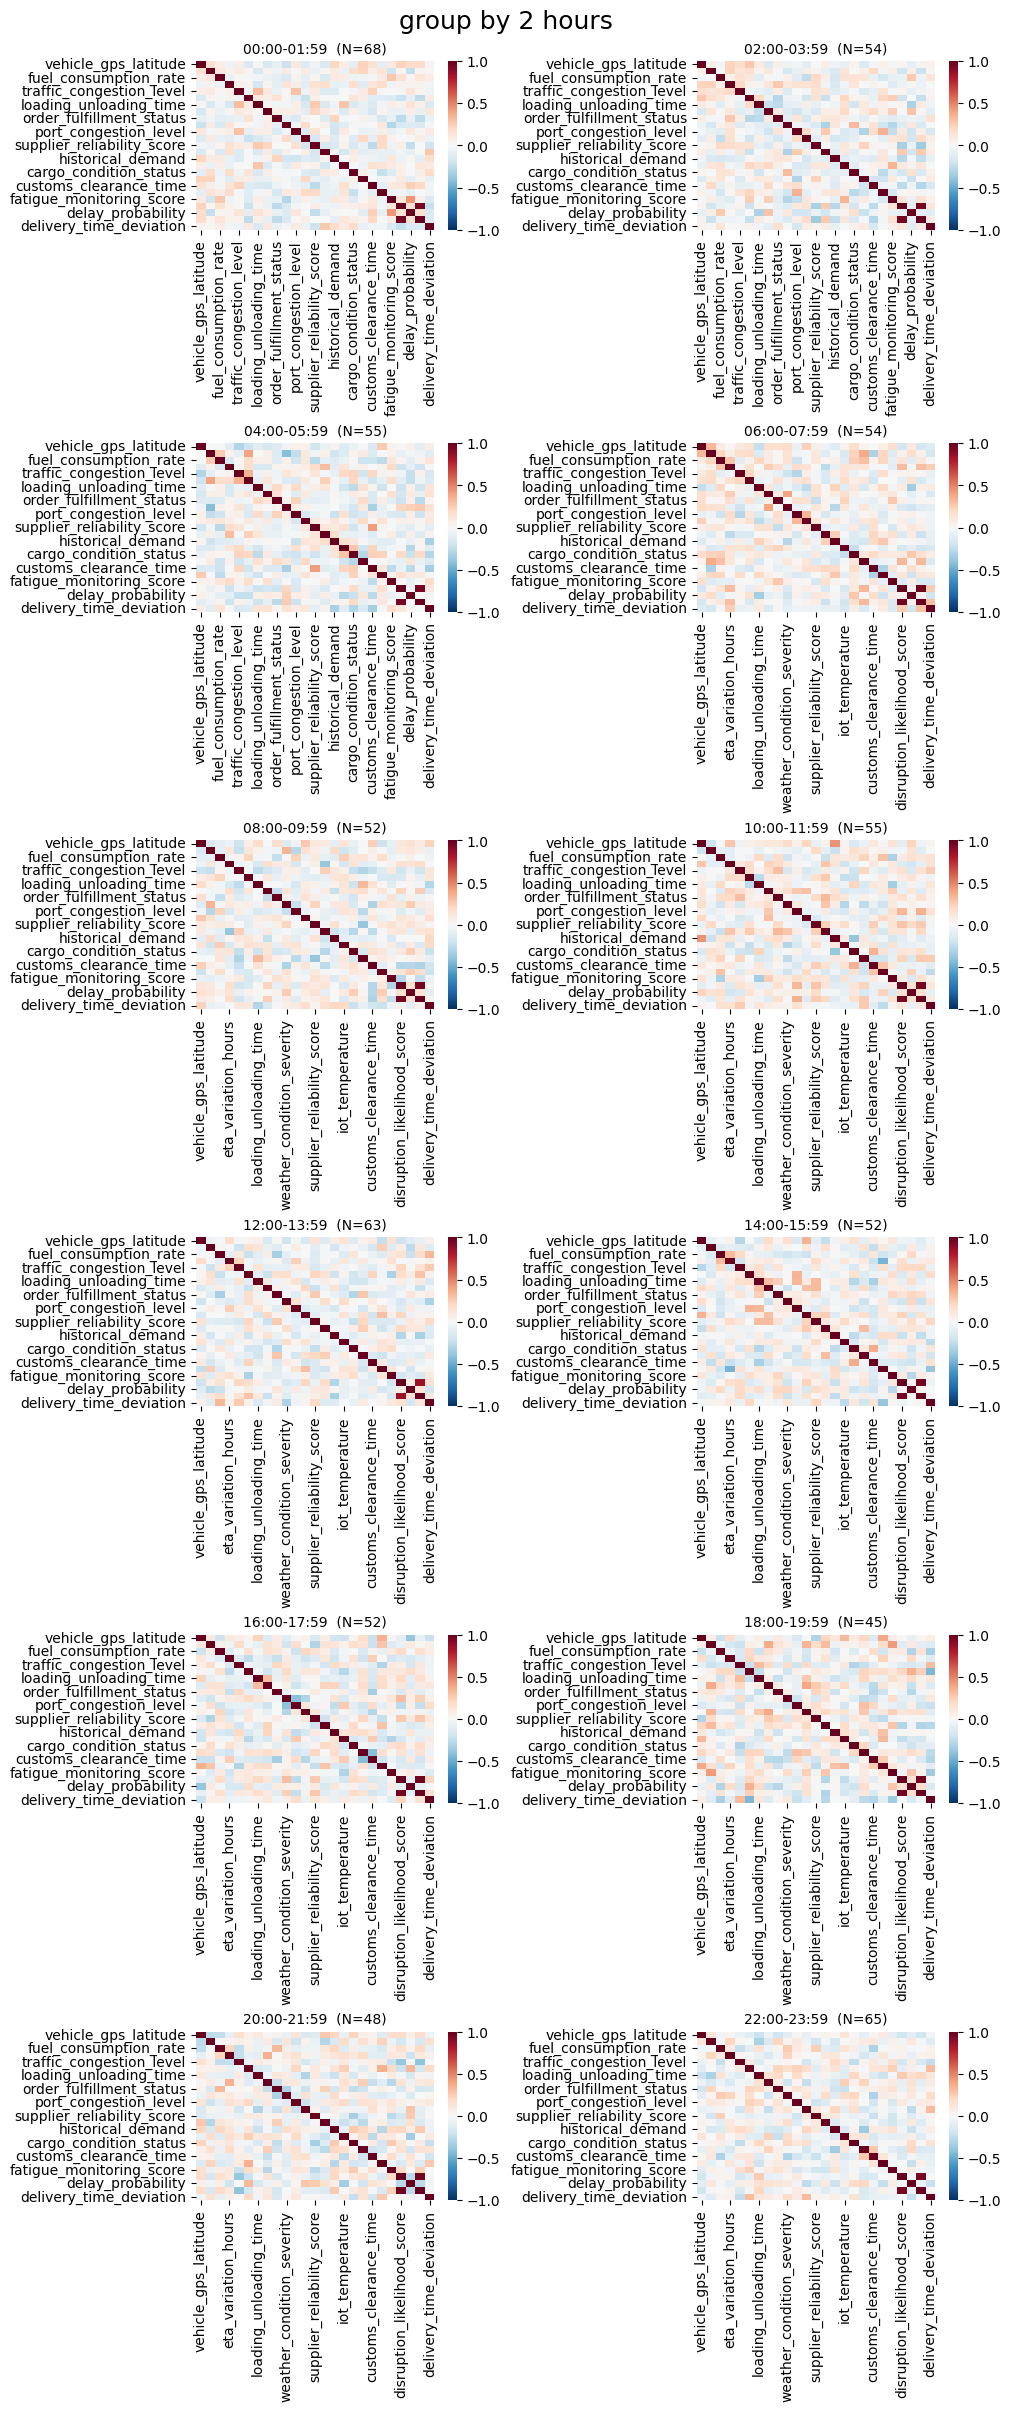

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if not isinstance(df.index, pd.DatetimeIndex):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')

hour_bin = df.index.hour // 2

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(6, 2, figsize=(10, 24), constrained_layout=True)
axes = axes.flatten()

def bin_title(b):
    start_h = int(b) * 2
    end_h = start_h + 1
    return f"{start_h:02d}:00-{end_h:02d}:59"

for b in range(12):
    ax = axes[b]
    grp = df[hour_bin == b]
    use_cols = [c for c in numeric_cols if c in grp.columns]
    corr = grp[use_cols].corr(numeric_only=True)
    sns.heatmap(
        corr,
        vmin=-1, vmax=1, center=0,
        cmap='RdBu_r', annot=False,
        cbar=True, ax=ax
    )
    ax.set_title(f"{bin_title(b)}  (N={len(grp)})", fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

for k in range(12, len(axes)):
    axes[k].axis('off')

plt.suptitle('group by 2 hours', fontsize=18)
plt.show()


## correlation analysis

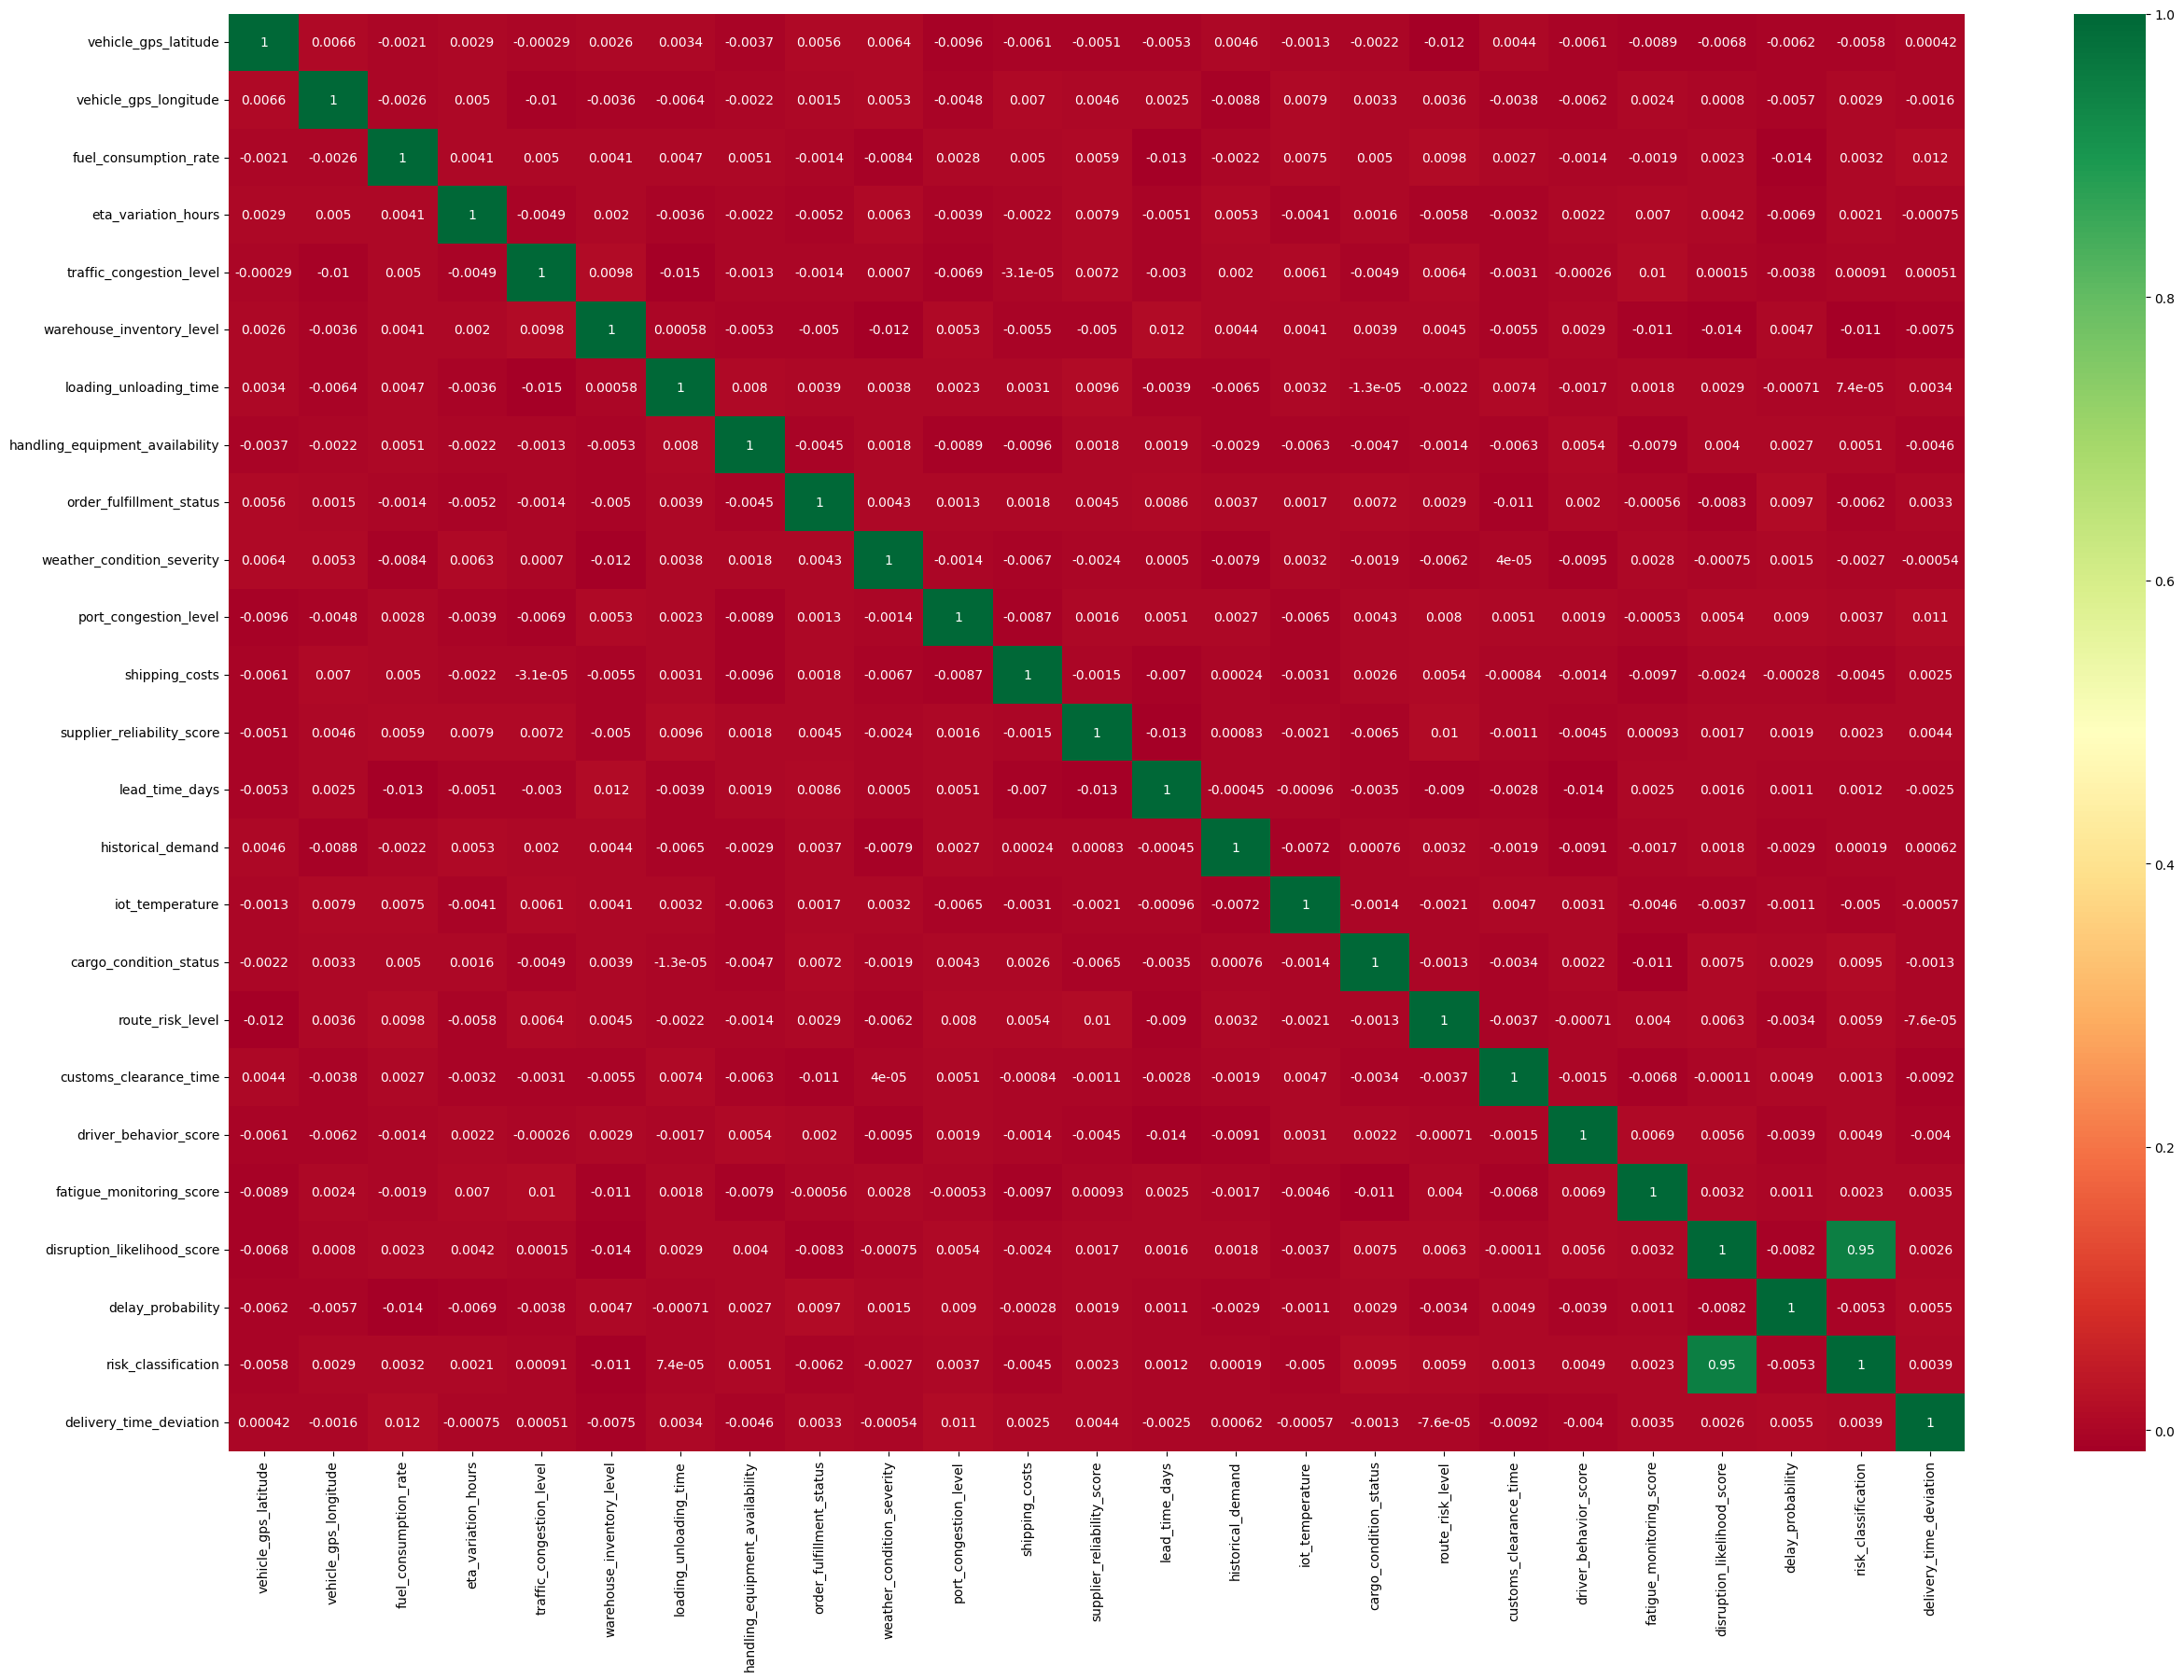

In [ ]:
corrmap = df.corr()
top=corrmap.index
plt.figure(figsize=(30,20))
g=sns.heatmap(df[top].corr(),annot=True,cmap="RdYlGn")

## data overview

In [ ]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()


数据集包含 25 个数值特征:
 1. vehicle_gps_latitude
 2. vehicle_gps_longitude
 3. fuel_consumption_rate
 4. eta_variation_hours
 5. traffic_congestion_level
 6. warehouse_inventory_level
 7. loading_unloading_time
 8. handling_equipment_availability
 9. order_fulfillment_status
10. weather_condition_severity
11. port_congestion_level
12. shipping_costs
13. supplier_reliability_score
14. lead_time_days
15. historical_demand
16. iot_temperature
17. cargo_condition_status
18. route_risk_level
19. customs_clearance_time
20. driver_behavior_score
21. fatigue_monitoring_score
22. disruption_likelihood_score
23. delay_probability
24. risk_classification
25. delivery_time_deviation

数据时间范围: 2021-01-01 00:00:00 到 2024-08-29 00:00:00
总数据点数: 32065


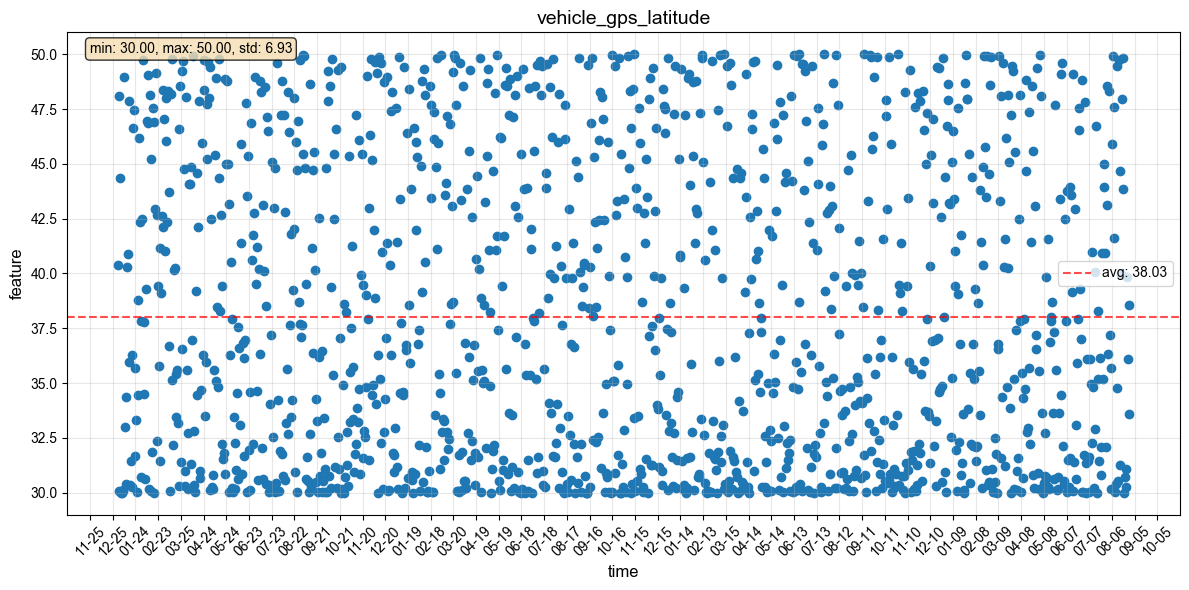

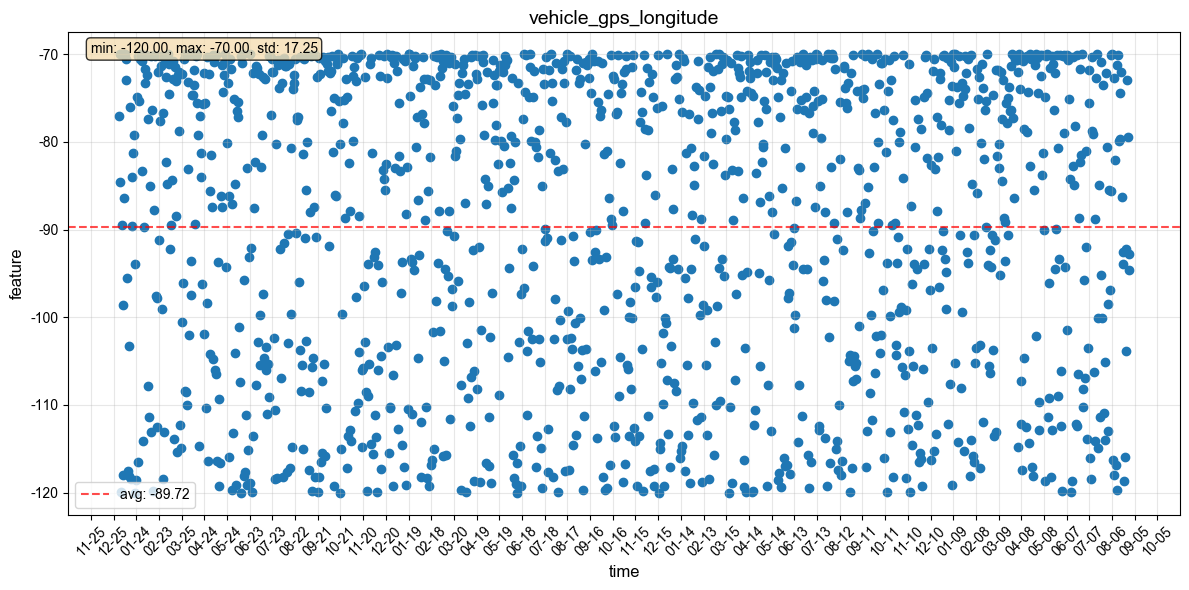

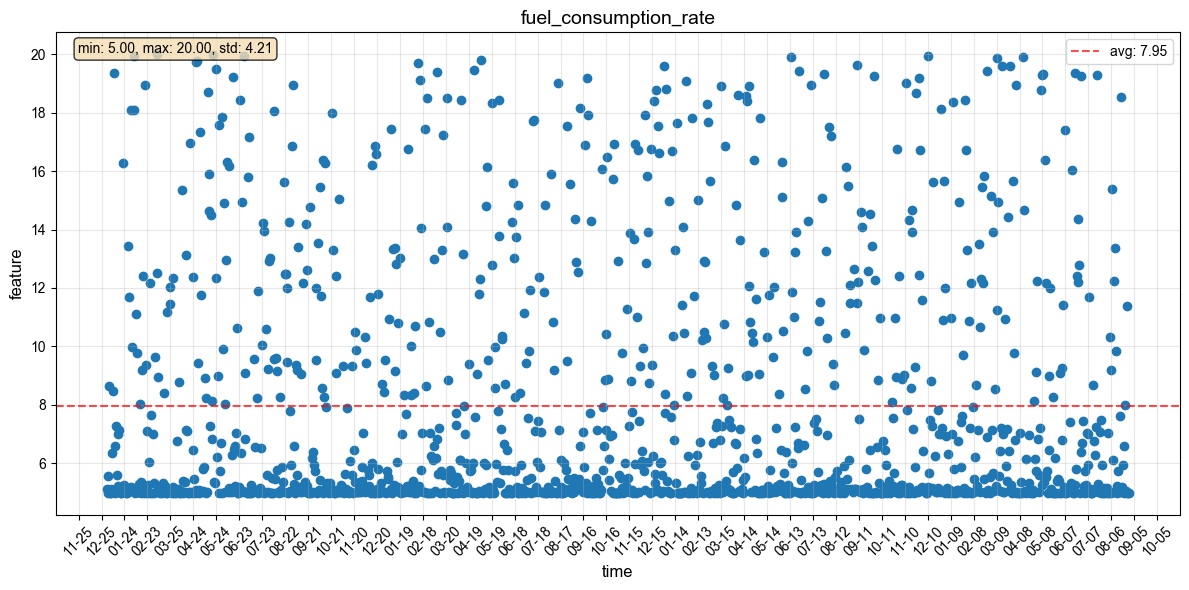

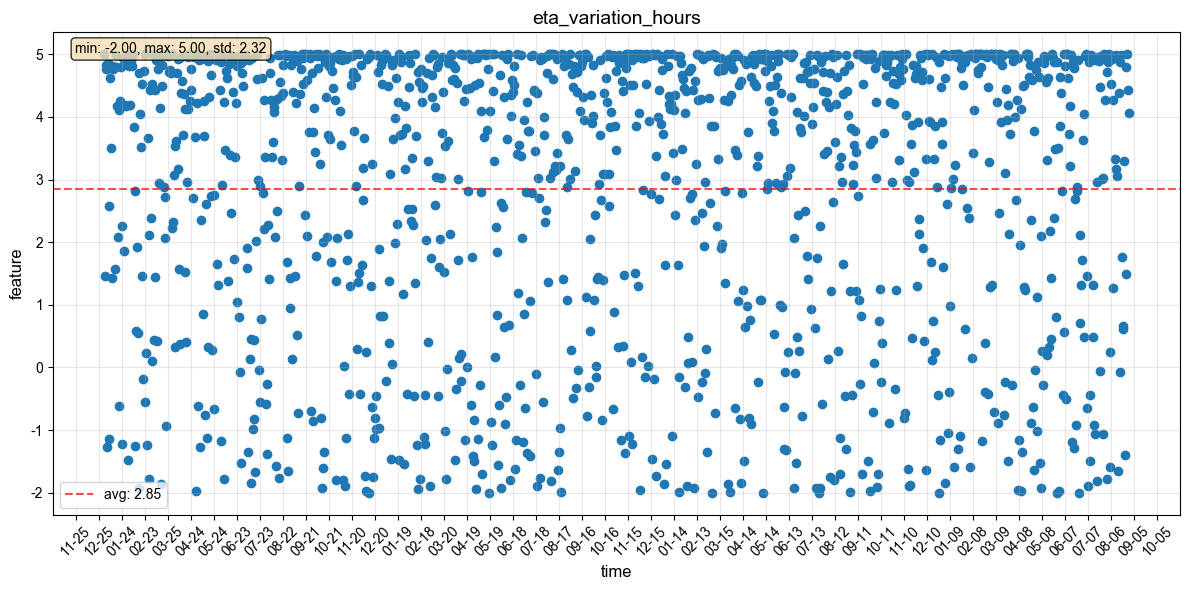

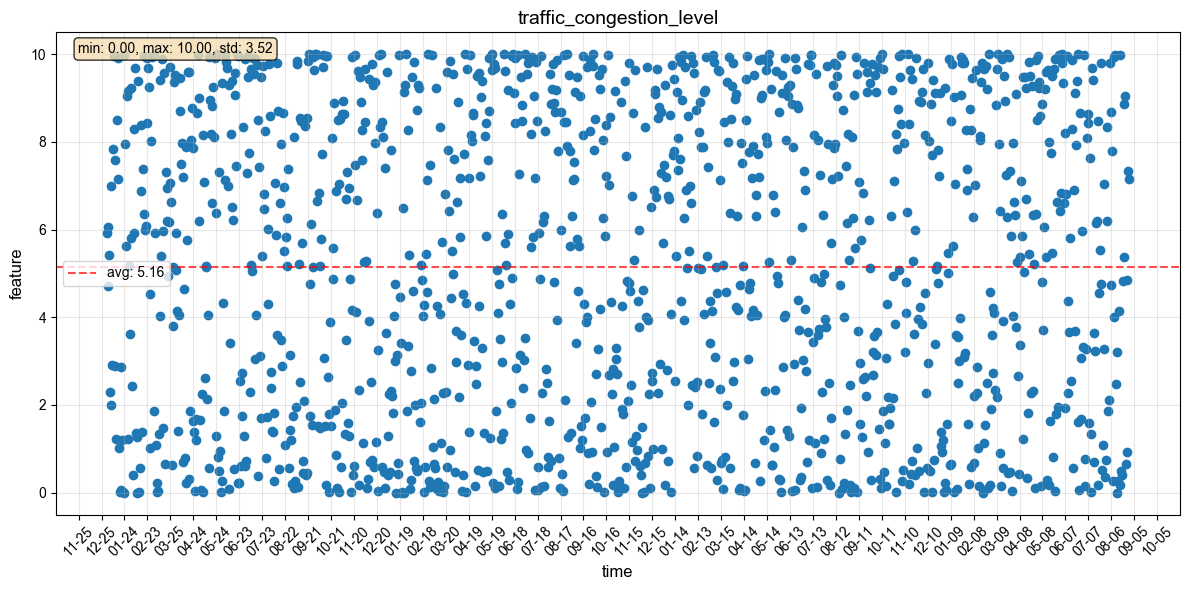

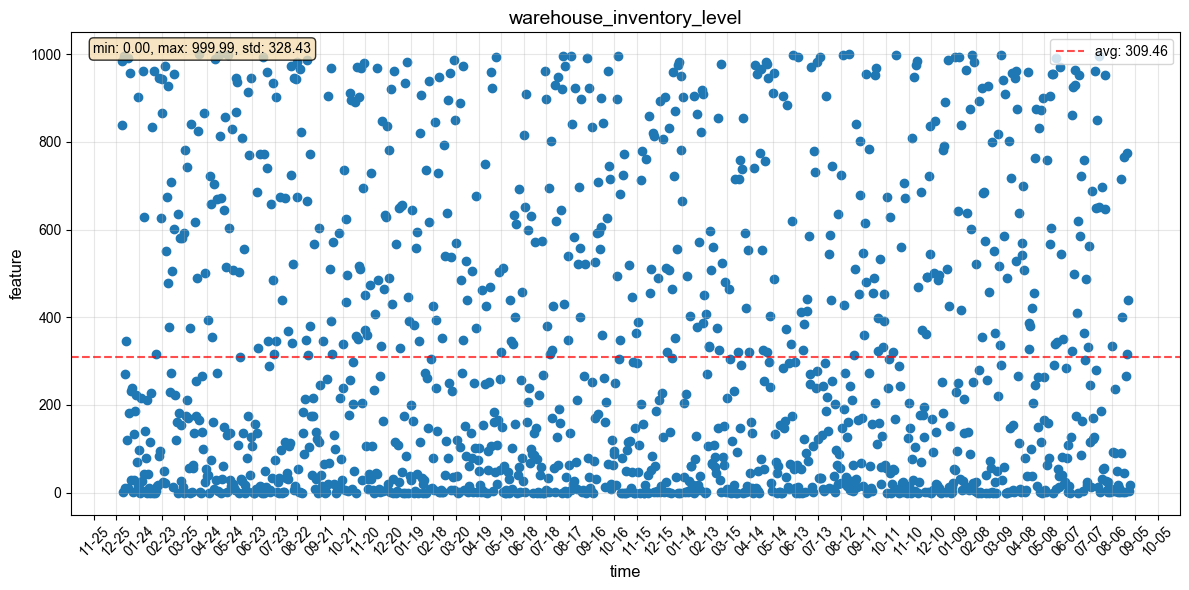

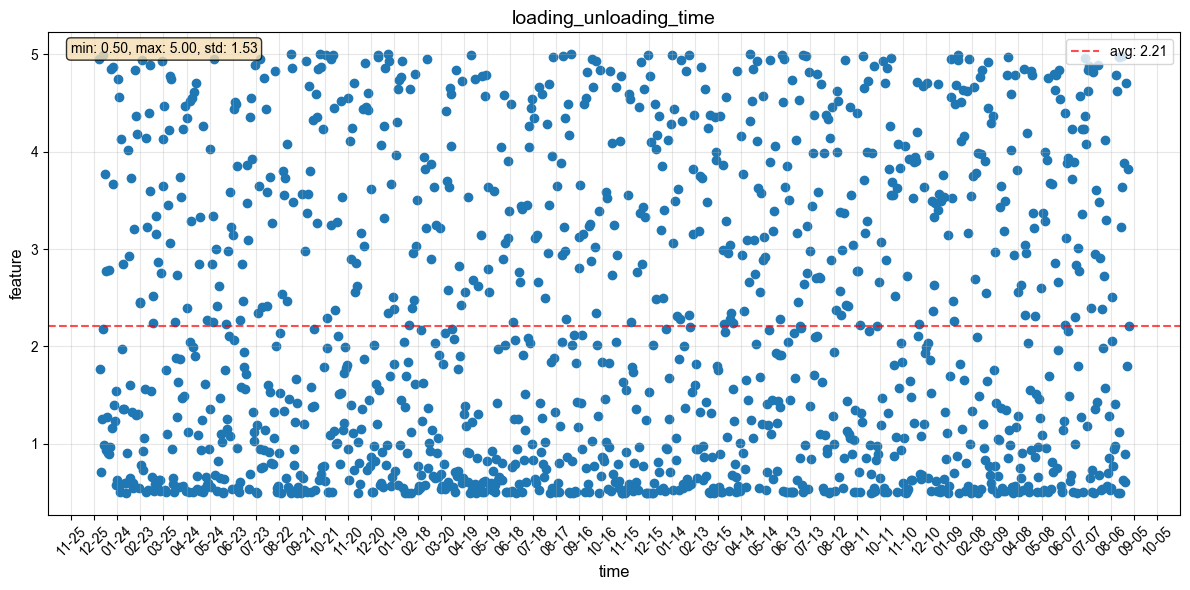

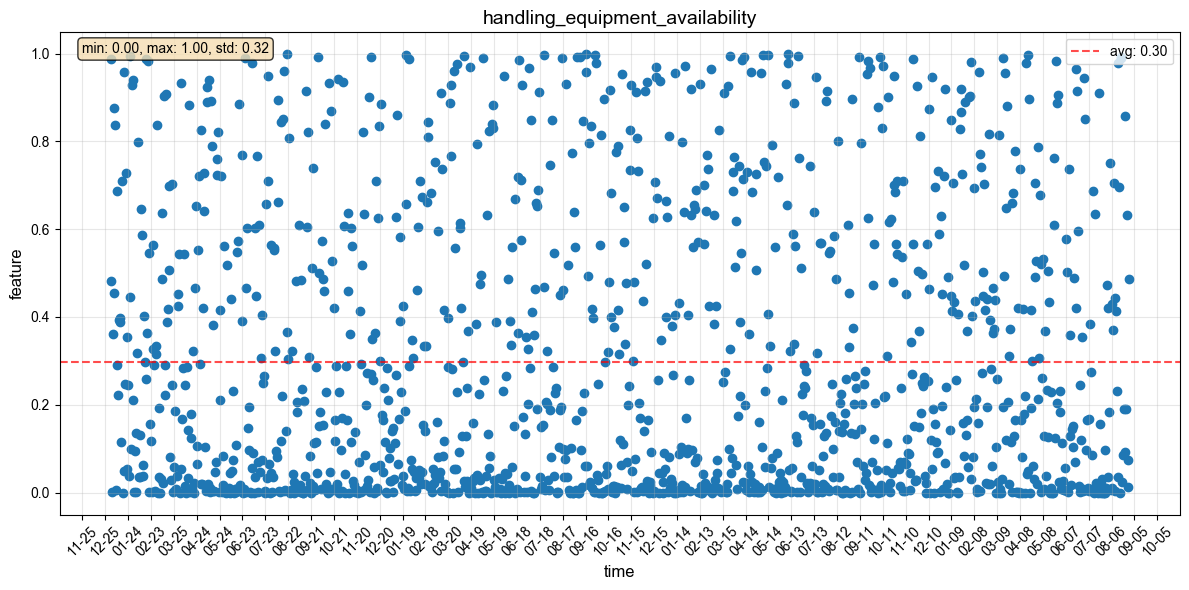

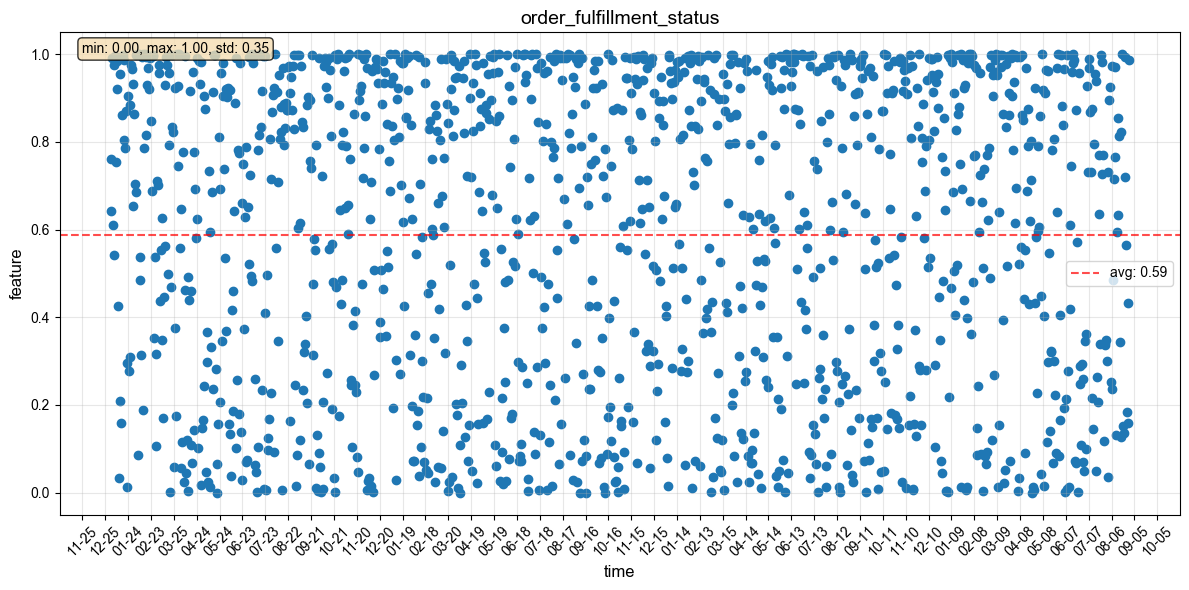

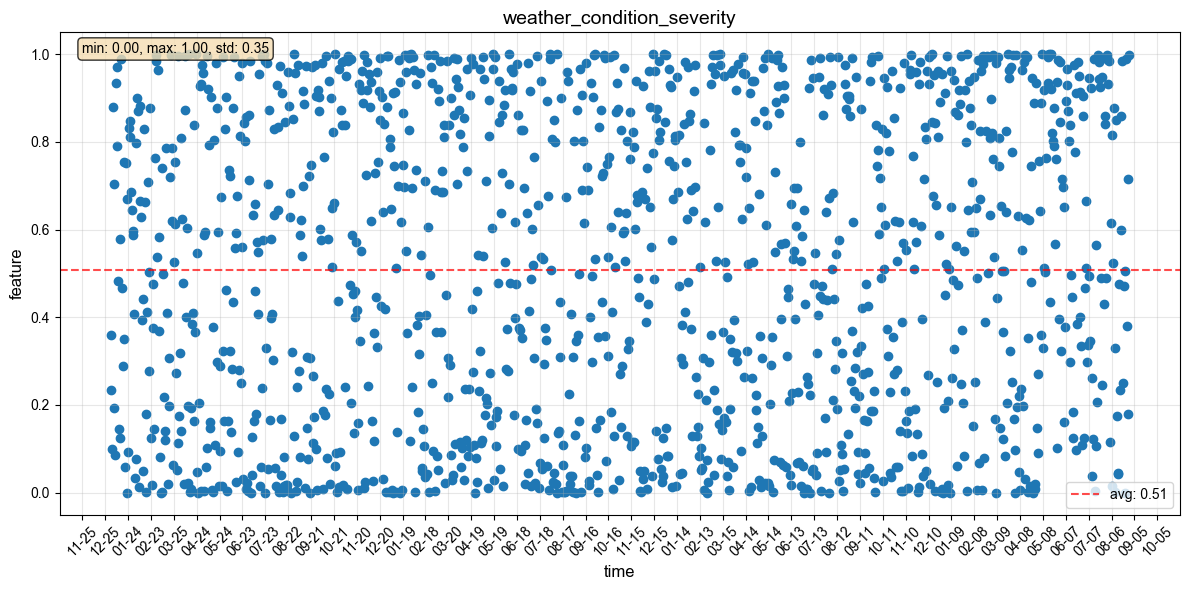

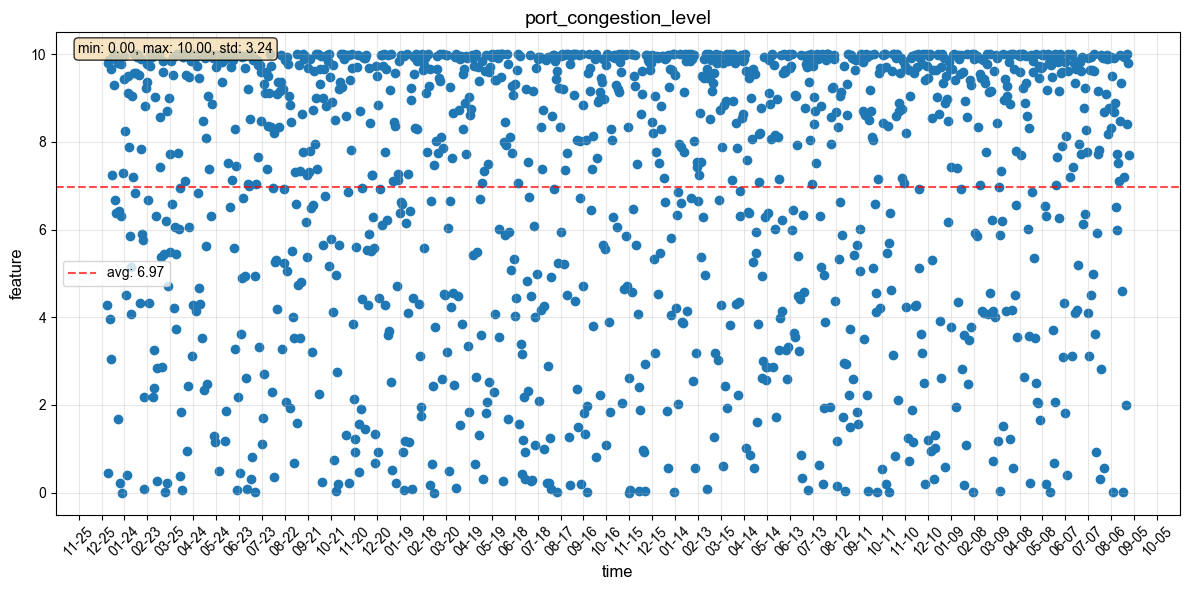

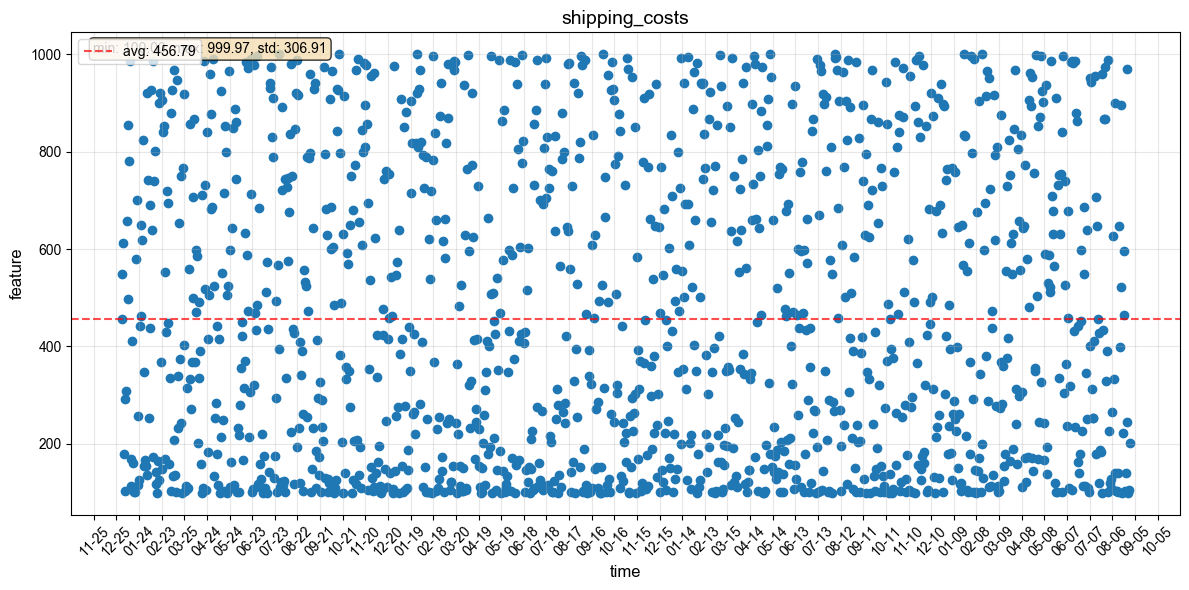

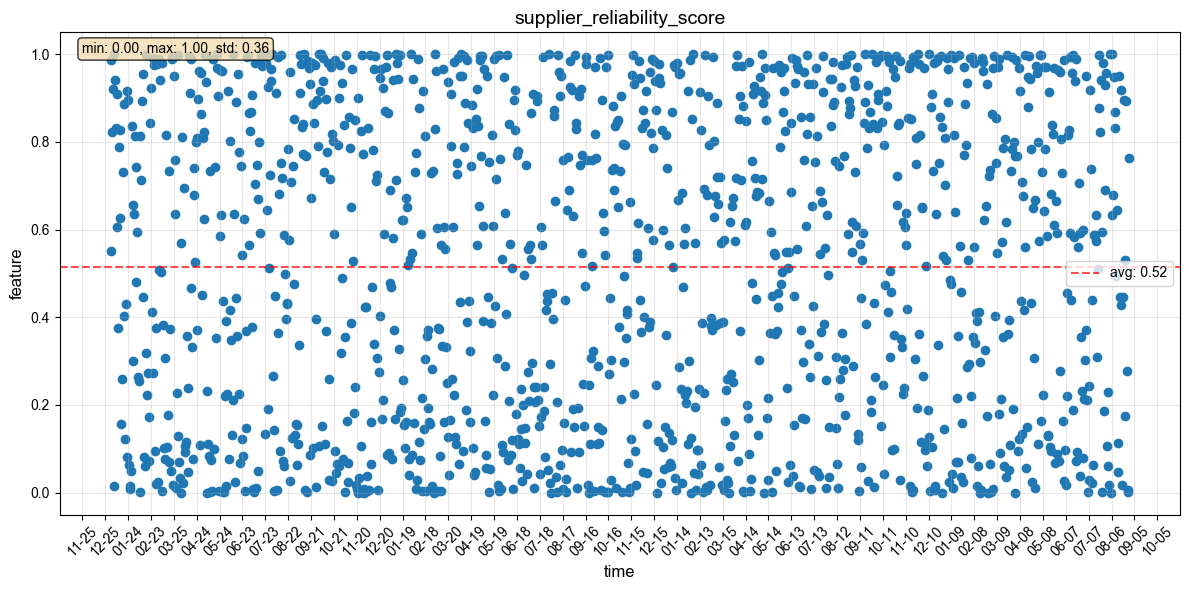

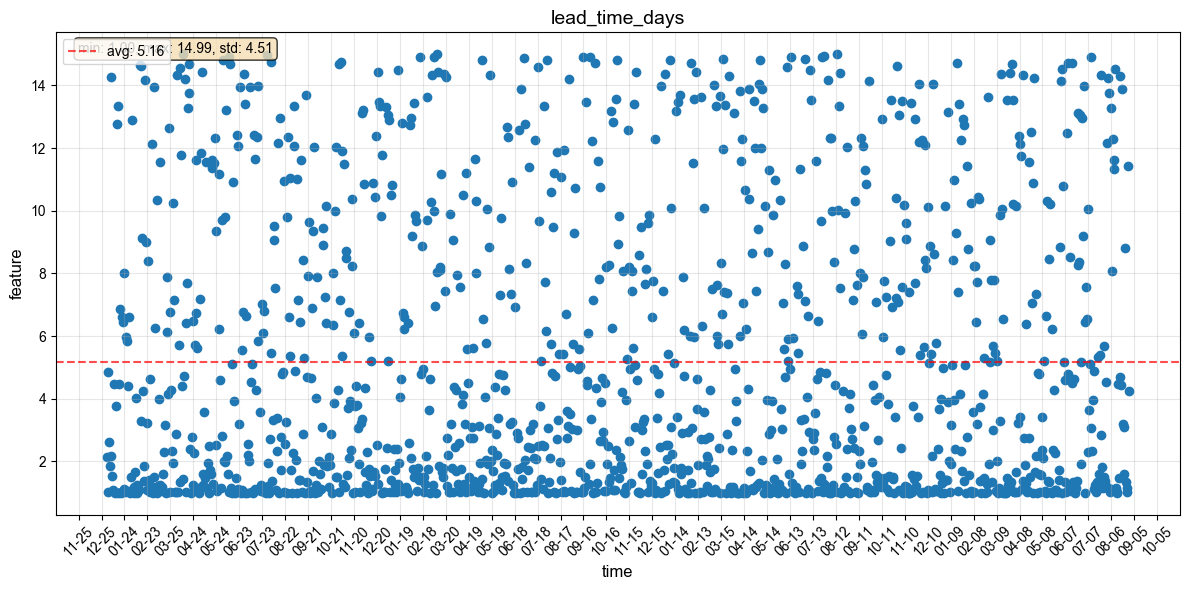

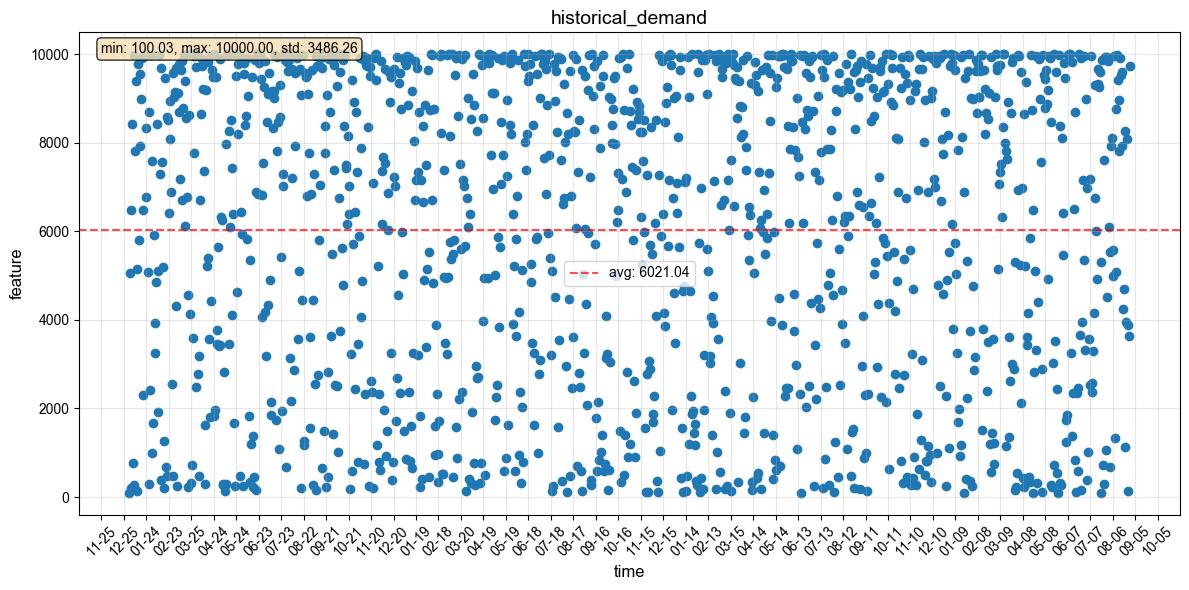

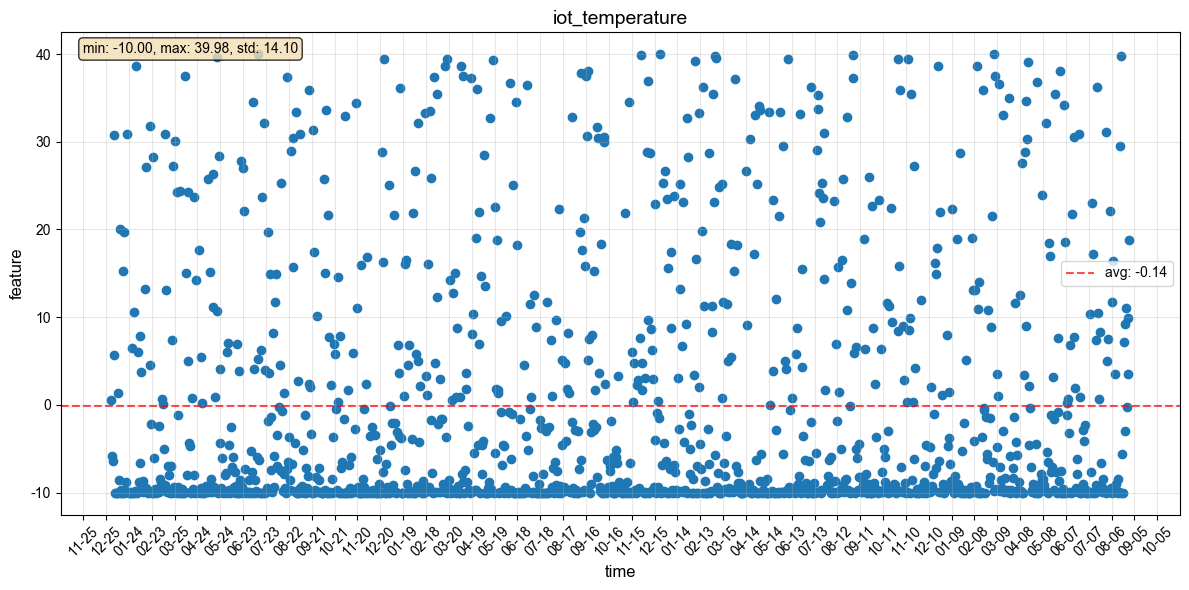

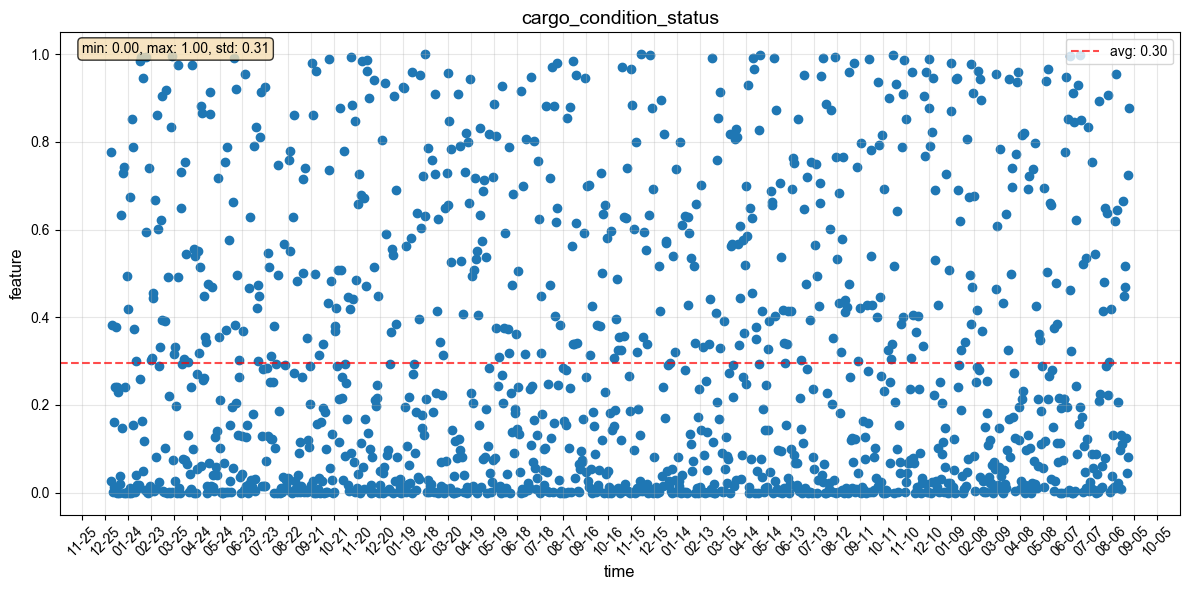

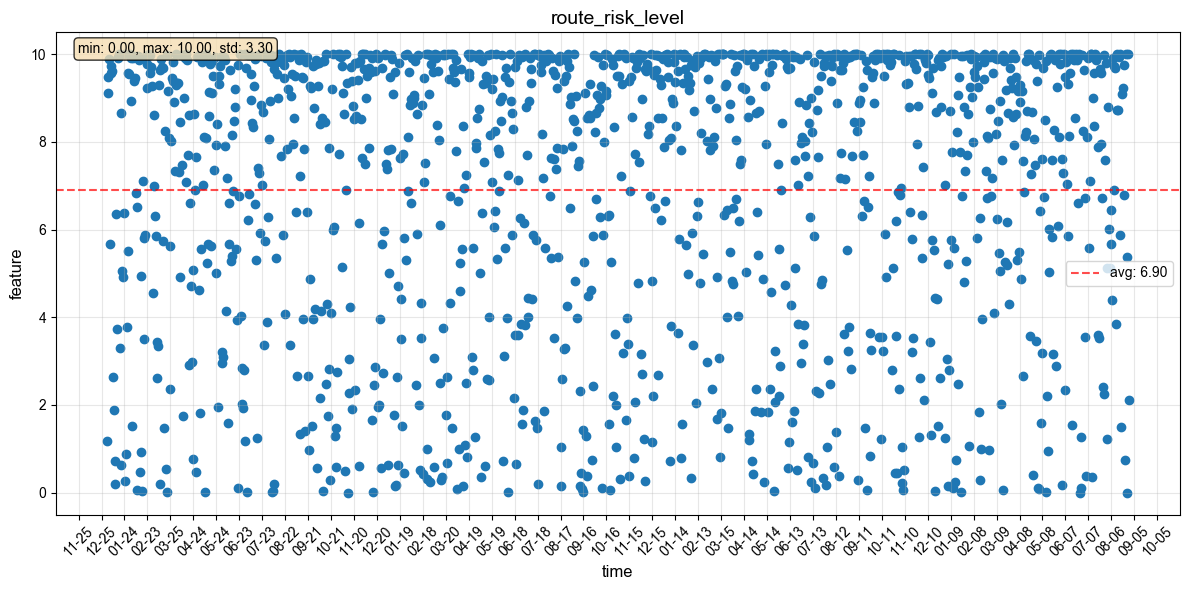

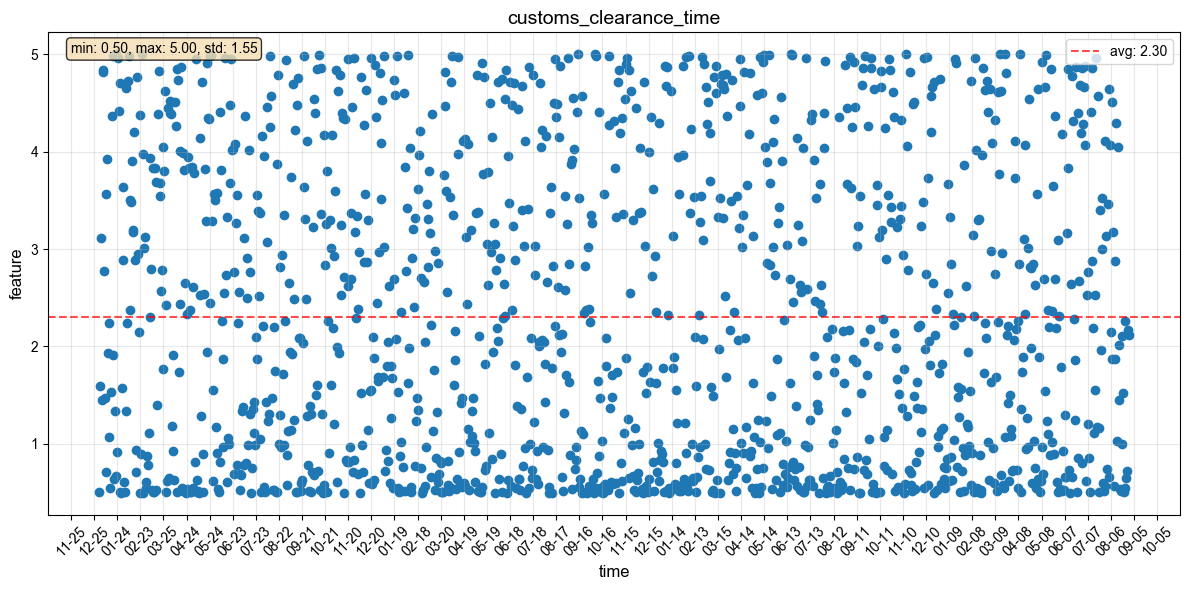

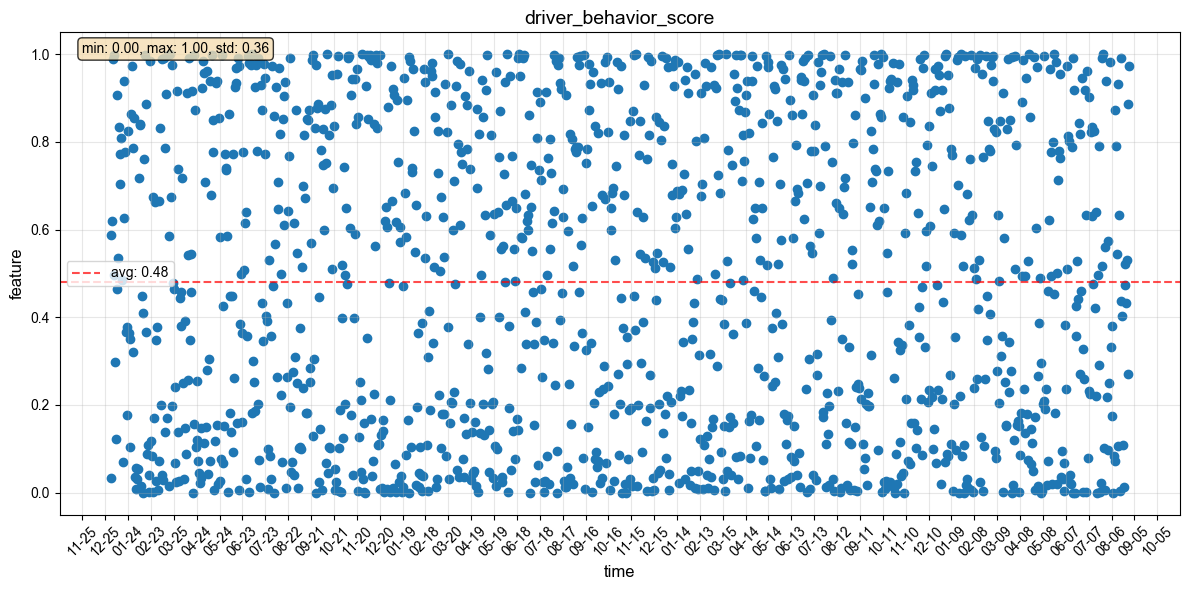

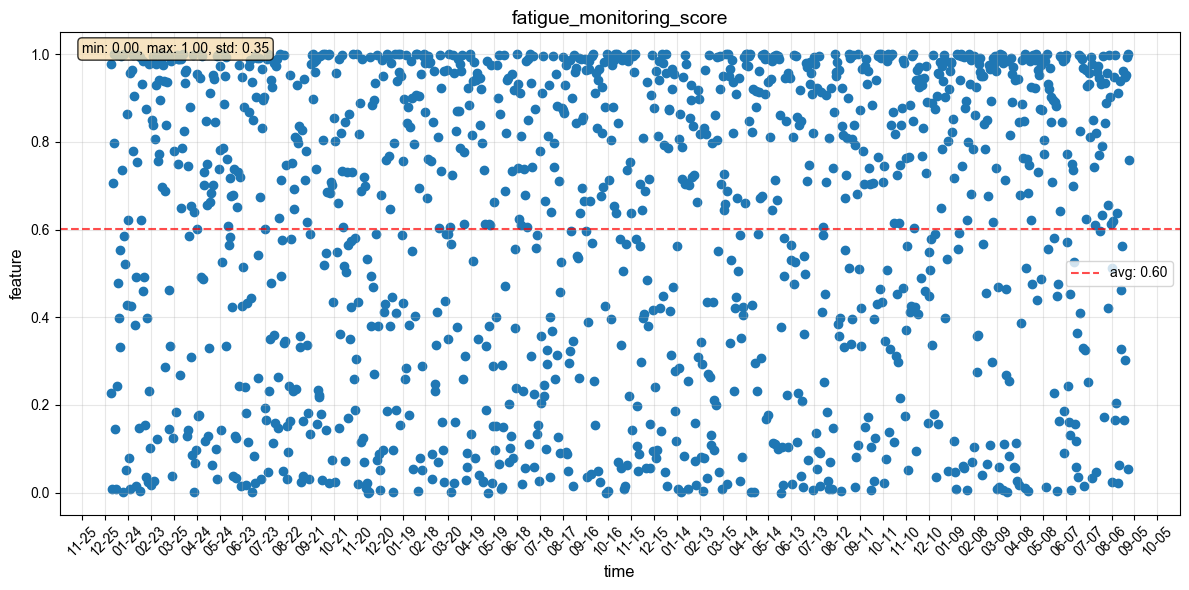

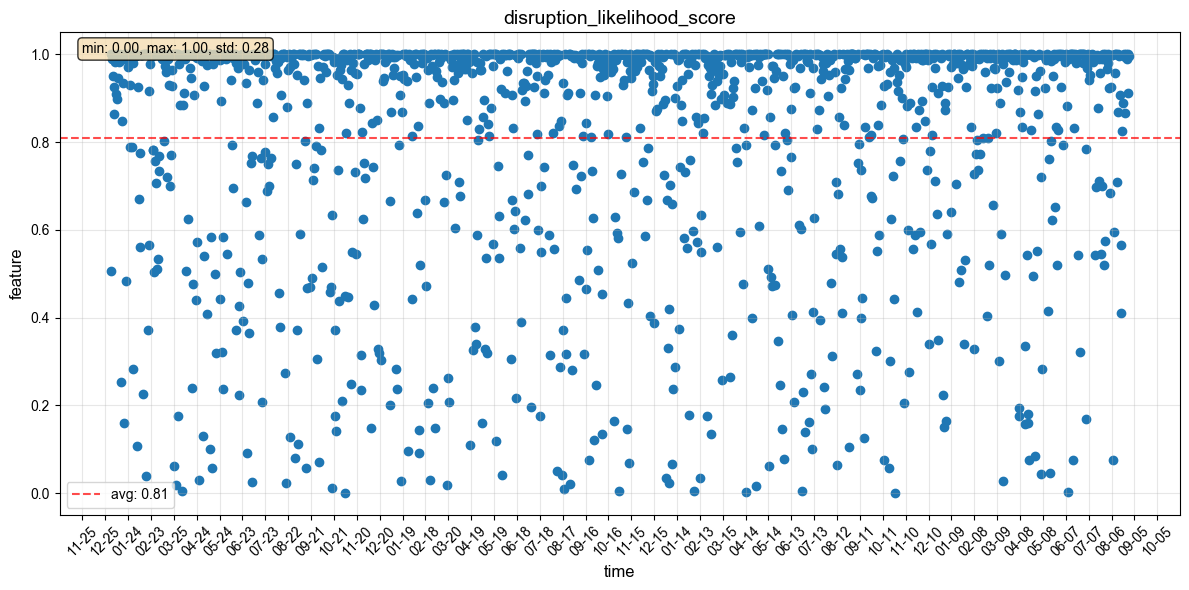

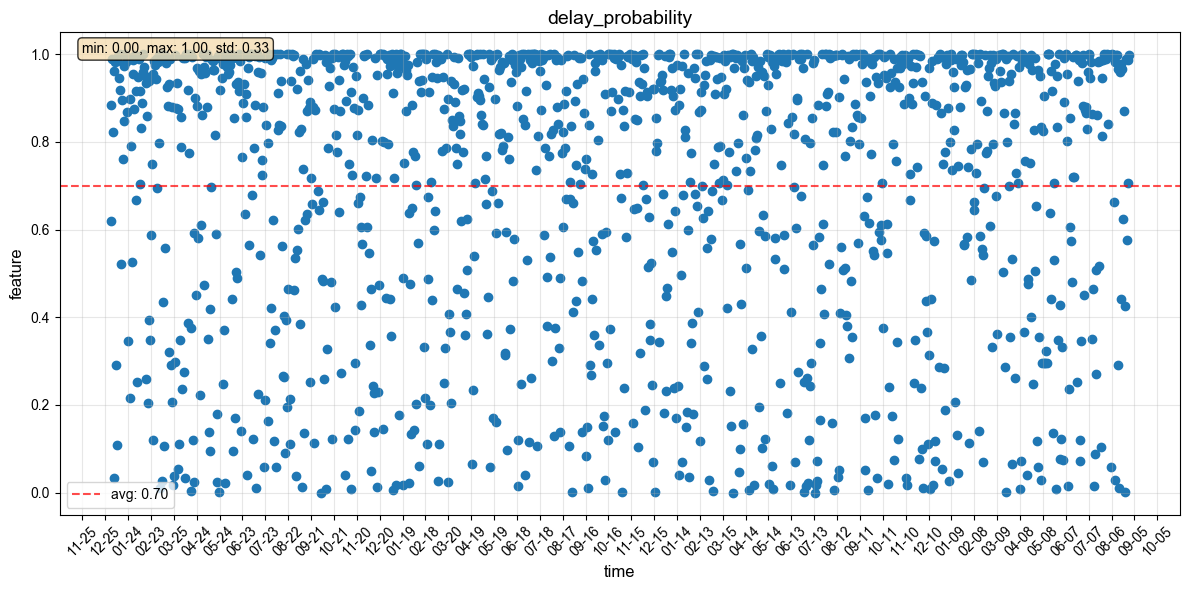

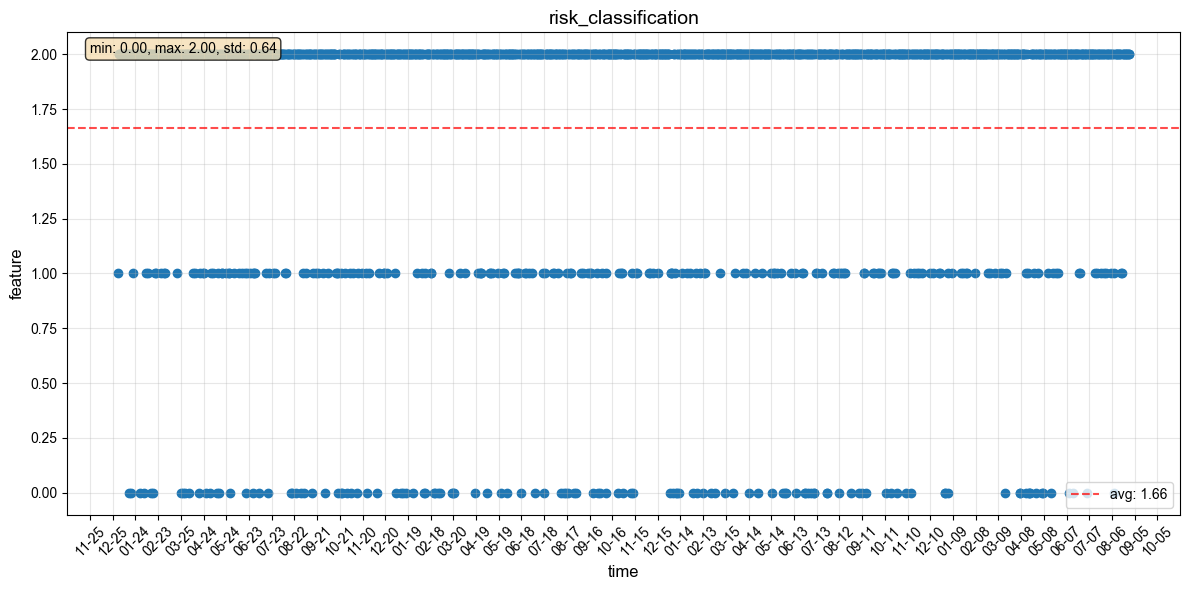

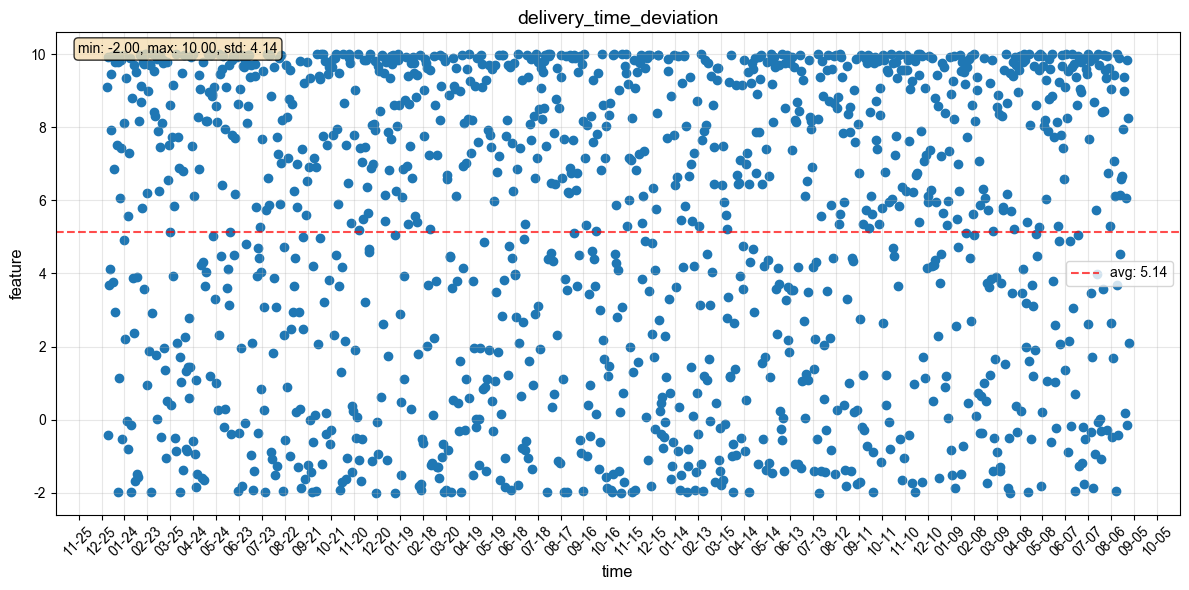

In [38]:
def generate_all_feature_plots(data, features):
    for i, feature in enumerate(features):
        
        plt.figure(figsize=(12, 6))
        
        plt.scatter(data.index, data[feature])
        
        plt.title(f'{feature}', fontsize=14, fontweight='bold')
        plt.xlabel('time', fontsize=12)
        plt.ylabel('feature', fontsize=12)
        
        plt.gca().xaxis.set_major_formatter(DateFormatter('%m-%d'))
        plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=30))
        plt.xticks(rotation=45)
        
        plt.grid(True, alpha=0.3)
        
        mean_val = data[feature].mean()
        std_val = data[feature].std()
        min_val = data[feature].min()
        max_val = data[feature].max()
        
        plt.axhline(y=mean_val, color='red', linestyle='--', alpha=0.7, label=f'avg: {mean_val:.2f}')
        plt.legend()
        
        stats_text = f'min: {min_val:.2f}, max: {max_val:.2f}, std: {std_val:.2f}'
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        
        plt.show()

generate_all_feature_plots(df[::24], numeric_features)


## model training

In [67]:
input_features = [
    'iot_temperature', 'loading_unloading_time', 'lead_time_days', 'fatigue_monitoring_score'
]

target_variables = [
    'disruption_likelihood_score'
]


In [68]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
X = df[input_features].values
y_disruption = df['disruption_likelihood_score'].values
# y_delay = df['delay_probability'].values
# y_deviation = df['delivery_time_deviation'].values
# y_risk = df['risk_classification'].values

X_train, X_test, y_disruption_train, y_disruption_test = train_test_split(
    X, y_disruption, test_size=0.2, random_state=42
)
# _, _, y_delay_train, y_delay_test = train_test_split(
#     X, y_delay, test_size=0.2, random_state=42
# )
# _, _, y_deviation_train, y_deviation_test = train_test_split(
#     X, y_deviation, test_size=0.2, random_state=42
# )
# _, _, y_risk_train, y_risk_test = train_test_split(
#     X, y_risk, test_size=0.2, random_state=42
# )

print(f"train set: {X_train.shape}")
print(f"test set: {X_test.shape}")

xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 100,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42
}

print("train model 1: disruption_likelihood_score")
model_disruption = xgb.XGBRegressor(**xgb_params)
model_disruption.fit(X_train, y_disruption_train)

# print("train model 2: delay_probability")
# model_delay = xgb.XGBRegressor(**xgb_params)
# model_delay.fit(X_train, y_delay_train)

# print("train model 3: delivery_time_deviation")
# model_deviation = xgb.XGBRegressor(**xgb_params)
# model_deviation.fit(X_train, y_deviation_train)

# print("train model 4: risk_classification")
# model_risk = xgb.XGBRegressor(**xgb_params)
# model_risk.fit(X_train, y_risk_train)



train set: (208, 4)
test set: (53, 4)
train model 1: disruption_likelihood_score


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'rmse'


In [69]:
y_disruption_pred = model_disruption.predict(X_test)
# y_delay_pred = model_delay.predict(X_test)
# y_deviation_pred = model_deviation.predict(X_test)
# y_risk_pred = model_risk.predict(X_test)

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} results:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = {}
results['disruption'] = evaluate_model(y_disruption_test, y_disruption_pred, "Disruption Likelihood Score")
# results['delay'] = evaluate_model(y_delay_test, y_delay_pred, "Delay Probability")
# results['deviation'] = evaluate_model(y_deviation_test, y_deviation_pred, "Delivery Time Deviation")
# results['risk'] = evaluate_model(y_risk_test, y_risk_pred, "Risk Classification")



Disruption Likelihood Score results:
MSE: 0.0962
RMSE: 0.3102
MAE: 0.2487
R²: -0.5321


In [70]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

try:
    import xgboost as xgb
    HAS_XGB = True
except:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except:
    HAS_LGB = False

input_features = [
    'iot_temperature', 'loading_unloading_time', 'lead_time_days', 'fatigue_monitoring_score'
]
target_variables = ['disruption_likelihood_score']

X = df[input_features].fillna(0)
y = df[target_variables[0]].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

if HAS_XGB:
    models["XGBoost"] = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )

if HAS_LGB:
    models["LightGBM"] = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=-1,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )

print("="*60)
print("comparison: input feature =", input_features, " | target =", target_variables[0])
print("="*60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"[{name:15s}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")


comparison: input feature = ['iot_temperature', 'loading_unloading_time', 'lead_time_days', 'fatigue_monitoring_score']  | target = disruption_likelihood_score
[LinearRegression]  MAE=0.2095  RMSE=0.0624  R²=0.0063
[RandomForest   ]  MAE=0.2375  RMSE=0.0826  R²=-0.3149
[GradientBoosting]  MAE=0.2565  RMSE=0.1122  R²=-0.7864
[XGBoost        ]  MAE=0.2512  RMSE=0.0930  R²=-0.4810


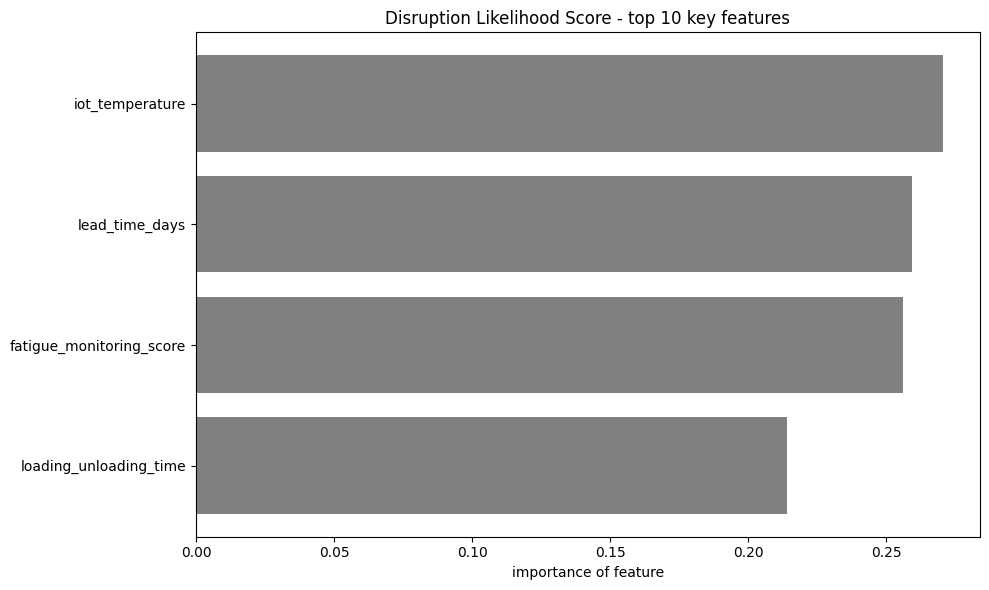

In [77]:
from turtle import color
import matplotlib.pyplot as plt

def plot_feature_importance(model, model_name, top_n=10):
    importance = model.feature_importances_
    feature_names = input_features
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(top_n)
    plt.barh(range(len(top_features)), top_features['importance'],color="gray")
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('importance of feature')
    plt.title(f'{model_name} - top {top_n} key features')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    return importance_df

disruption_importance = plot_feature_importance(model_disruption, "Disruption Likelihood Score")
# delay_importance = plot_feature_importance(model_delay, "Delay Probability")
# deviation_importance = plot_feature_importance(model_deviation, "Delivery Time Deviation")
# risk_importance = plot_feature_importance(model_risk, "Risk Classification")


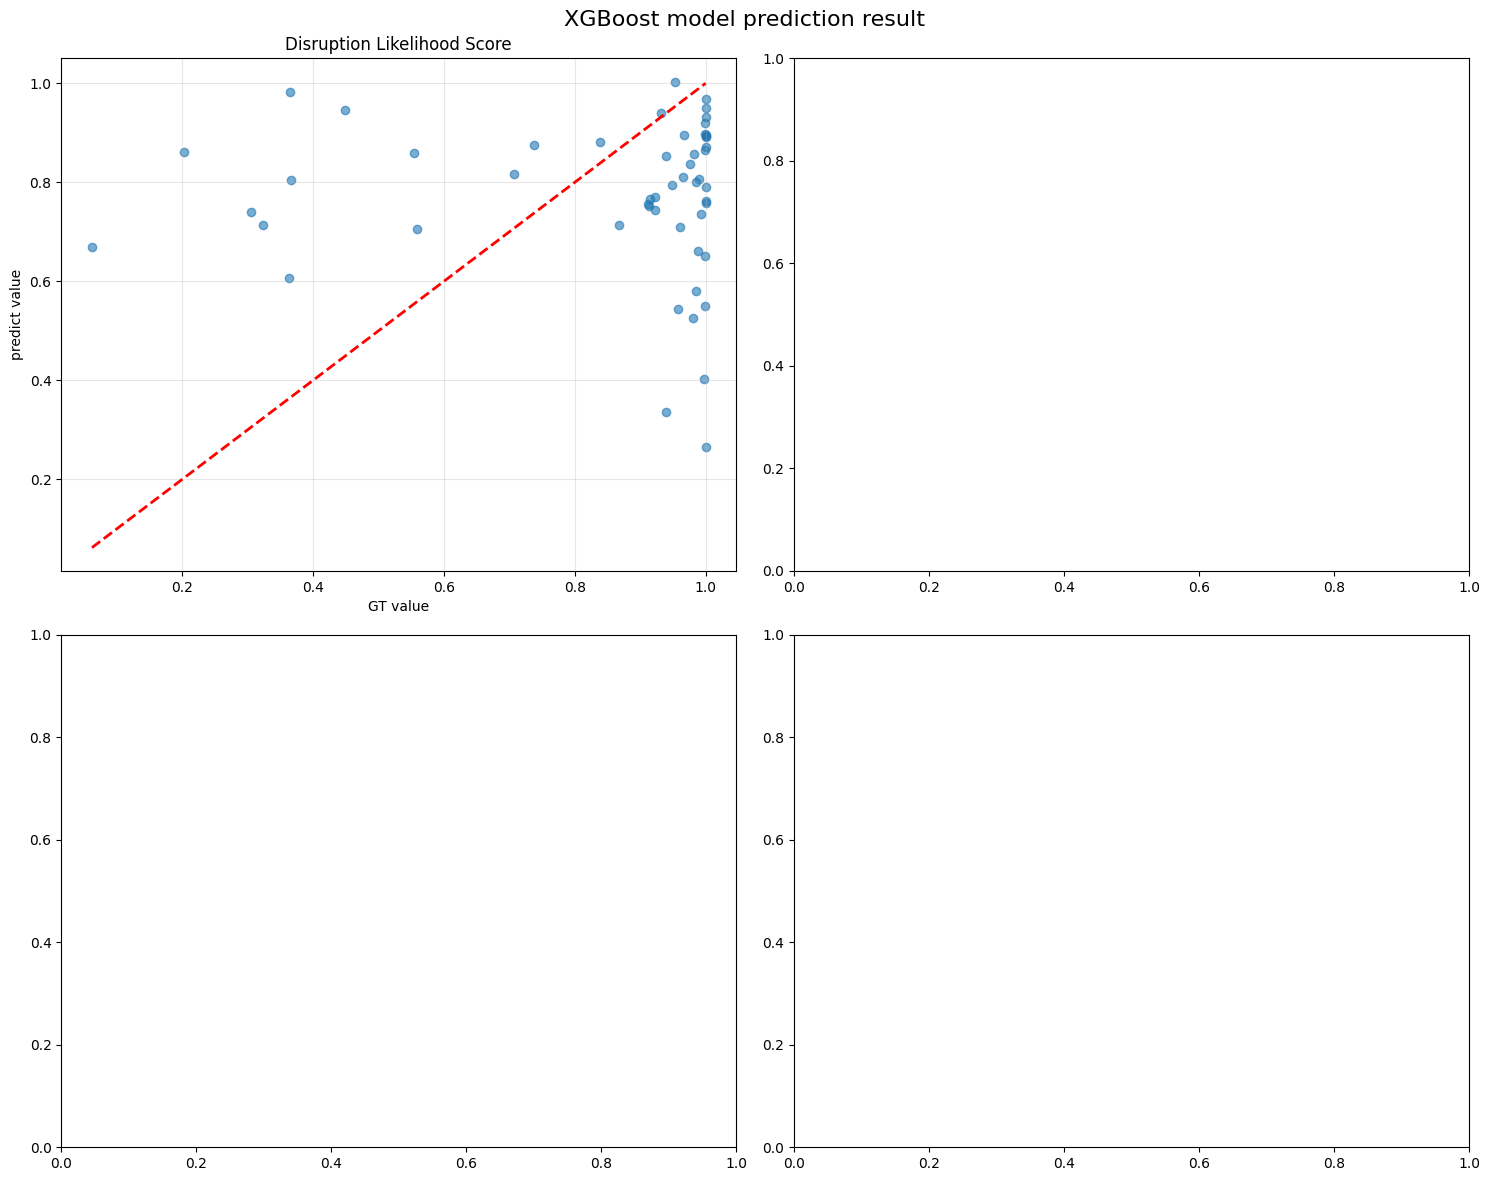

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('XGBoost model prediction result', fontsize=16)

# 1. Disruption Likelihood Score
axes[0,0].scatter(y_disruption_test, y_disruption_pred, alpha=0.6)
axes[0,0].plot([y_disruption_test.min(), y_disruption_test.max()], 
               [y_disruption_test.min(), y_disruption_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('GT value')
axes[0,0].set_ylabel('predict value')
axes[0,0].set_title('Disruption Likelihood Score')
axes[0,0].grid(True, alpha=0.3)

# # 2. Delay Probability
# axes[0,1].scatter(y_delay_test, y_delay_pred, alpha=0.6)
# axes[0,1].plot([y_delay_test.min(), y_delay_test.max()], 
#                [y_delay_test.min(), y_delay_test.max()], 'r--', lw=2)
# axes[0,1].set_xlabel('实际值')
# axes[0,1].set_ylabel('预测值')
# axes[0,1].set_title('Delay Probability')
# axes[0,1].grid(True, alpha=0.3)

# # 3. Delivery Time Deviation
# axes[1,0].scatter(y_deviation_test, y_deviation_pred, alpha=0.6)
# axes[1,0].plot([y_deviation_test.min(), y_deviation_test.max()], 
#                [y_deviation_test.min(), y_deviation_test.max()], 'r--', lw=2)
# axes[1,0].set_xlabel('实际值')
# axes[1,0].set_ylabel('预测值')
# axes[1,0].set_title('Delivery Time Deviation')
# axes[1,0].grid(True, alpha=0.3)

# # 4. Risk Classification
# axes[1,1].scatter(y_risk_test, y_risk_pred, alpha=0.6)
# axes[1,1].plot([y_risk_test.min(), y_risk_test.max()], 
#                [y_risk_test.min(), y_risk_test.max()], 'r--', lw=2)
# axes[1,1].set_xlabel('实际值')
# axes[1,1].set_ylabel('预测值')
# axes[1,1].set_title('Risk Classification')
# axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
